In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Generator , Literal
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.messages import SystemMessage,  ToolMessage
from pydantic import BaseModel, Field
from typing import List,operator
from langgraph.types import Send
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langchain.agents import create_agent
from langgraph.constants import Send

/Users/fakhrulislamfahad/Documents/Personal/agentic-ai/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/4y/hrml6n2j2nsdvdx747c5gmhr0000gn/T/ipykernel_11340/1822943232.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun
/var/folders/4y/hrml6n2j2nsdvdx747c5gmhr0000gn/T/ipykernel_11340/1822943232.py:22: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [2]:
llm = ChatOllama(model="qwen2.5:7b", temperature=0)

In [3]:
class CodeState(TypedDict):
    query : str
    task: str           # user's coding request
    code: str           # generated code
    output: str         # execution result or error
    status: str         # "passed" or "failed"
    retries: int        # how many attempts so far
    error: str          # last error message if any

In [15]:
class CodeStructure(BaseModel):
    query : str
    output : str

In [4]:
def extract_code(raw: str) -> str:
    if "```python" in raw:
        raw = raw.split("```python")[1].split("```")[0]
    elif "```" in raw:
        raw = raw.split("```")[1].split("```")[0]
    return raw.strip()

# ── Nodes ─────────────────────────────────────────────────
def code_generator(state: CodeState):
    # ✅ different prompt on retry — includes the error
    if state["error"]:
        prompt = f"""You are an expert Python programmer.

Your previous code failed with this error:
{state["error"]}

Previous code:
{state["code"]}

Fix the code for this task: {state["query"]}

Rules:
- Store the final result in a variable named `answer`
- Output ONLY raw Python code, no markdown, no backticks
- No explanations
"""
    else:
        prompt = f"""You are an expert Python programmer.

Write Python code for this task: {state["query"]}

Rules:
- Store the final result in a variable named `answer`
- Output ONLY raw Python code, no markdown, no backticks
- No explanations
"""
    output = llm.invoke(prompt)
    clean_code = extract_code(output.content)  # ✅ strip backticks

    print(f"\n[Attempt {state['retries'] + 1}] Generated code:")
    print(clean_code)

    return {"code": clean_code}

def execute_code(state: CodeState):
    namespace = {}
    try:
        exec(state["code"], namespace)
        answer = namespace.get("answer", "No `answer` variable found")

        print(f"[Execute] ✅ Passed — answer: {answer}")
        return {
            "output": str(answer),
            "status": "passed",
            "error": "",
            "retries": state["retries"] + 1  # ✅ increment retries
        }

    except Exception as e:
        print(f"[Execute] ❌ Failed — error: {e}")
        return {
            "output": "",
            "status": "failed",
            "error": str(e),
            "retries": state["retries"] + 1  # ✅ increment retries
        }

def should_retry(state: CodeState) -> str:
    if state["status"] == "passed":
        print(f"✅ Done in {state['retries']} attempt(s)")
        return "end"
    if state["retries"] >= 3:
        print(f"❌ Failed after {state['retries']} attempts")
        return "end"
    print(f"🔄 Retrying... attempt {state['retries']}")
    return "retry"

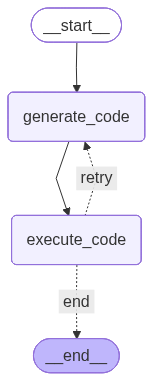

In [5]:
builder = StateGraph(CodeState)
builder.add_node("generate_code", code_generator)
builder.add_node("execute_code",  execute_code)

builder.add_edge(START, "generate_code")
builder.add_edge("generate_code", "execute_code")
builder.add_conditional_edges(
    "execute_code",
    should_retry,
    {
        "retry": "generate_code",
        "end":   END,
    }
)

graph = builder.compile()
graph


In [6]:
res = graph.invoke({
    'query' : 'Write a function that returns the sum of a list of numbers and test it with [1,2,3,4,5]',
    'task': ' '    ,       # user's coding request
    'code': ' '   ,        # generated code
    'output': ' '   ,      # execution result or error
    'status': ' '   ,      # "passed" or "failed"
    'retries': 0 ,      # how many attempts so far
    'error': ' ' 
})
res


[Attempt 1] Generated code:
def sum_list(numbers):
    answer = sum(numbers)
    return answer

print(sum_list([1,2,3,4,5]))
15
[Execute] ✅ Passed — answer: No `answer` variable found
✅ Done in 1 attempt(s)


{'query': 'Write a function that returns the sum of a list of numbers and test it with [1,2,3,4,5]',
 'task': ' ',
 'code': 'def sum_list(numbers):\n    answer = sum(numbers)\n    return answer\n\nprint(sum_list([1,2,3,4,5]))',
 'output': 'No `answer` variable found',
 'status': 'passed',
 'retries': 1,
 'error': ''}